# 🧭 Introduction to Supervised Machine Learning
### From finding structure to predicting answers

**Module 1 · Session 09 · lecture notebook**

Lecture notes for session 09, in notebook form. Run all cells (Runtime → Run all) and read top to bottom.
The charts are drawn from the nomad cities data used in sessions 06–08; the plotting code is folded away
and can be opened with *Show code*. Practice notebooks: part 1 and part 2 (links at the end).

<img src="https://raw.githubusercontent.com/aaubs/ds-master/main/media/M1_2026/sml09/nomad.jpg" width="520">

Contents
1. Where we are: from structure to prediction
2. The vocabulary: targets, losses, models
3. Honest evaluation: baselines, test sets, leakage
4. Classification and thresholds
5. Model families and interpretation
6. Practice: pipelines and tuning

In [1]:
# @title Setup: libraries and chart style { display-mode: "form" }
import warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, altair as alt
warnings.filterwarnings("ignore", message="Unknown solver options")   # harmless scipy noise from LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, NMF
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, mean_absolute_error, precision_score,
                             r2_score, recall_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from matplotlib.colors import LinearSegmentedColormap

NAVY, LAV, GREY, ORANGE = "#211A52", "#C2C1CC", "#54616E", "#D2542A"   # AAU palette, same as the slides
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.edgecolor": GREY, "axes.labelcolor": GREY,
                     "xtick.color": GREY, "ytick.color": GREY, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#E6E6EC", "legend.frameon": False})

In [2]:
# The nomad cities table from sessions 06-08
cities = pd.read_csv("https://sds-aau.github.io/SDS-master/M1/data/cities.csv")

# One broken value: Samara's racism score is 1.8e28 on a 0-1 scale. Replace it with the median.
cities.loc[cities["racism"] > 1, "racism"] = cities["racism"].median()
numeric = cities.select_dtypes("number")

# Supervised setup: cost_nomad is the target y. The other price columns are left out on purpose
# (a city without a cost report won't have them either; see the leakage section).
OTHER_PRICES = ["cost_coworking", "cost_expat", "coffee_in_cafe", "cost_beer"]
FEATURES = [c for c in numeric.columns if c not in ["cost_nomad", *OTHER_PRICES]]
X, y = cities[FEATURES], cities["cost_nomad"]

# Hold back 20 % of the cities; the models never see them while training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"{len(cities)} cities · {len(FEATURES)} features · {len(X_train)} train / {len(X_test)} test")

780 cities · 16 features · 624 train / 156 test


---
# 🗺️ 1 · Where we are

Sessions 06–08 worked with one table: 780 cities from Nomad List, with columns for cost, internet,
safety, freedom and nightlife.

| Session | Question asked of the table | Tool |
|---|---|---|
| 06 | Which few directions explain most of the variation? | PCA, UMAP, t-SNE |
| 07 | Which cities belong together? Which are the extremes? | k-means, archetypes |
| 08 | Which cities are most like this one? | similarity search |

All of these methods use only the columns, `X`. None of them is told what a right answer would be.

🖱️ The map below is interactive: hovering shows the city, and the chart can be zoomed.

In [3]:
# Sessions 06-07 in three lines: scale, compress to two components, cluster
Z = StandardScaler().fit_transform(numeric)
pcs = PCA(n_components=2).fit_transform(Z)
cluster = KMeans(n_clusters=4, n_init=10, random_state=42).fit(Z).labels_

In [4]:
# @title Draw the interactive map { display-mode: "form" }
view = cities[["place", "alpha-2", "region", "cost_nomad"]].assign(
    pc1=pcs[:, 0].round(2), pc2=pcs[:, 1].round(2), cluster=[f"cluster {k}" for k in cluster])
pick = alt.selection_point(fields=["cluster"], bind="legend")
dots = alt.Chart(view).mark_circle(size=45).encode(
    x=alt.X("pc1:Q", title="first component"), y=alt.Y("pc2:Q", title="second component"),
    color=alt.Color("cluster:N", scale=alt.Scale(range=[NAVY, LAV, GREY, ORANGE]), title="k-means"),
    opacity=alt.condition(pick, alt.value(0.85), alt.value(0.08)),
    tooltip=[alt.Tooltip("place:N", title="city"), alt.Tooltip("alpha-2:N", title="country"), "region:N",
             alt.Tooltip("cost_nomad:Q", title="USD / month", format=",.0f"), "cluster:N"],
).add_params(pick, alt.selection_interval(bind="scales"))
label = alt.Chart(view[view.place == "Aalborg"]).mark_text(dx=10, dy=-10, align="left", fontWeight="bold", color=NAVY
    ).encode(x="pc1:Q", y="pc2:Q", text="place:N")
(dots + label).properties(width=640, height=400, title="780 cities · hover for details · scroll to zoom · click the legend")

alt.LayerChart(...)

### 🧩 One more unsupervised idea: NMF

PCA gives directions that are positive and negative at the same time, which makes them hard to read.
**Non-negative matrix factorisation** only allows non-negative numbers, so each component becomes a *theme*
built from a handful of columns, and every city is a mix of those themes, like ingredients in a recipe.

In [5]:
# NMF needs non-negative input, so scale every column to 0-1 first
Xn = numeric.drop(columns=["cost_beer"])                 # identical to coffee_in_cafe in every row
scaled = MinMaxScaler().fit_transform(Xn)

nmf = NMF(n_components=4, init="nndsvda", random_state=0, max_iter=2000).fit(scaled)
W = nmf.transform(scaled)                                # cities x themes: how much of each theme a city has
H = pd.DataFrame(nmf.components_, columns=Xn.columns)    # themes x columns: what each theme is made of

# The model only returns numbers; the names are ours, read off each theme's strongest column
H = H.div(H.max(axis=1), axis=0)
label = {"nightlife": "Buzz & lifestyle", "fragile_states_index": "Fragile & restricted",
         "weed": "Cannabis (one column)", "peace_score": "Safe & open"}
names = [label[H.iloc[i].idxmax()] for i in range(4)]
for i, n in enumerate(names):
    print(f"{n:24s}", ", ".join(cities.loc[np.argsort(-W[:, i])[:3], "place"]))

Buzz & lifestyle         Monaco, Tel Aviv, Miami
Fragile & restricted     Khartoum, Dalian, Linyi
Cannabis (one column)    Santiago, Ploiesti, Chicago
Safe & open              Reykjavik, Nanaimo, Aalborg


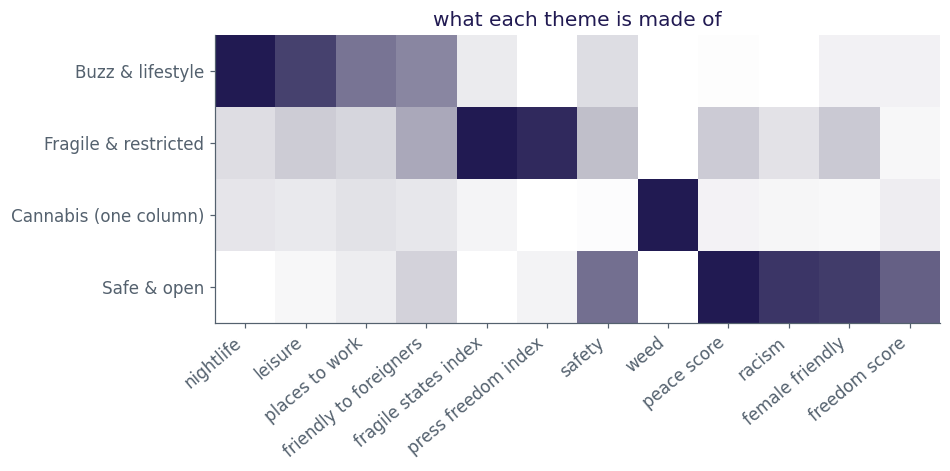

In [6]:
# @title Draw the themes { display-mode: "form" }
feats = list(dict.fromkeys(f for i in range(4) for f in H.iloc[i].sort_values(ascending=False).index[:4]))
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.imshow(H[feats].values, cmap=LinearSegmentedColormap.from_list("aau", ["#FFFFFF", LAV, NAVY]), aspect="auto")
ax.set_yticks(range(4), names); ax.set_xticks(range(len(feats)), [f.replace("_", " ") for f in feats], rotation=40, ha="right")
ax.grid(False); ax.set_title("what each theme is made of", color=NAVY)
plt.show()

The themes almost name themselves. One of them is simply *cannabis*: a single column strong enough to get a
theme of its own. The method has no notion of what is interesting.

🤔 *Question: which of these themes would predict cost best?*

None of the themes is about cost. NMF finds structure, but it is never asked about cost.

### How were those results judged?

By interpretability: whether the first component can be read, whether the city types make sense, whether
the recommendations are plausible. That is judgement, not a check against an answer key. Supervised
learning adds the answer key.

### 🙈 Hide one column

A new city appears on Nomad List. We know its internet speed, safety, freedom score, nightlife…
but nobody has reported what it **costs** to live there.

<img src="https://raw.githubusercontent.com/aaubs/ds-master/main/media/M1_2026/sml09/hide_column.jpg" width="480">

`cost_nomad` (monthly cost for a remote worker, in USD) becomes the thing to predict: **`y`**.
Everything else stays the features: **`X`**. Same table, one column promoted to target.

| | Unsupervised | Supervised |
|---|---|---|
| Input | `X` only | `X` **and** `y` |
| Question | What structure is in here? | Given `X`, what is `y`? |
| Output | components, clusters, neighbours | a prediction for a new row |
| Judged by | interpretability, usefulness | error on rows the model has **not seen** |

A right answer makes error measurable, and measurable error is what allows models to be compared, tuned
and checked for cheating.

### 🏘️ The similarity search is already a supervised model

Session 08: find the five cities most like Aalborg, with the cost columns hidden.

🤔 *Question: what would these neighbours suggest Aalborg costs?*

In [7]:
Zx = StandardScaler().fit_transform(X)
aalborg = cities.index[cities["place"] == "Aalborg"][0]
_, idx = NearestNeighbors(n_neighbors=6).fit(Zx).kneighbors(Zx[[aalborg]])
neighbours = [i for i in idx[0] if i != aalborg][:5]
display(cities.loc[neighbours, ["place", "alpha-2", "cost_nomad"]])
print(f"average of the neighbours: {cities.loc[neighbours, 'cost_nomad'].mean():,.0f}")
print(f"Aalborg, actual:           {cities.loc[aalborg, 'cost_nomad']:,.0f}")

,place,alpha-2,cost_nomad
159,Dunedin,NZ,2751.0
587,Aarhus,DK,4374.0
204,Moncton,CA,3238.0
691,Reykjavik,IS,4307.0
207,Brampton,CA,2247.0


average of the neighbours: 3,383
Aalborg, actual:           4,220


That average **is** a prediction. Averaging the neighbours' `y` is called **k-nearest-neighbours regression**,
and scikit-learn has it as one object:

In [8]:
others = cities.index != aalborg
knn = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5)).fit(X[others], y[others])
knn.predict(X.loc[[aalborg]])

array([3383.4])

Off by about 840 USD. Is that good or bad? We can't say yet: we need something to compare with.

### 🏷️ Clusters are not labels

The k-means clusters were built on all the columns, cost included. Do they answer *is this city expensive?*

In [9]:
# Do the k-means clusters answer "is this city expensive"? Share above 3,000 USD per cluster:
pd.crosstab(cluster, cities["cost_nomad"] > 3000, normalize="index")[True].round(2)

,True
row_0,
0,0.06
1,0.51
2,0.10
3,0.62


The clusters are related to cost, but one of them is close to a coin flip. A question about cost needs a model
that is given cost, which is what supervision means.

What carries over from unsupervised learning: scaling (`StandardScaler`), distance and similarity (kNN is
the session 08 search), components as features, and the `fit` / `transform` pattern, now with `predict`.

What is new: a target, a loss function, and a test set.

---
# 📖 2 · The vocabulary

1. **Unsupervised**: unlabelled data, find structure *(sessions 06–08)*
2. **Supervised**: labelled data, predict outcomes *(today)*
3. **Self-supervised**: make labels from the data itself: hide the next word, predict it *(how LLMs are pre-trained)*
4. **Reinforcement**: learn from rewards while interacting with an environment

The type of `y` decides the task: a number → **regression** (monthly cost); a category → **classification**
(expensive above 3,000 USD, or not). Same features, same workflow; different loss and metrics.

Key terms: training data, features and labels, model, loss, evaluation, and generalisation (doing well on
the next city, not the last one).

We look for parameters $\theta$ such that $y \approx f(X;\theta)$ **for cities the model has not seen**.
"$\approx$" needs a definition: the loss.

| Mean squared error (regression) | Cross-entropy (classification) |
|---|---|
| $\text{MSE} = \frac{1}{n}\sum_i (y_i - \hat y_i)^2$ | $H(p,q) = -\sum_k p_k \log q_k$ |
| Squaring punishes big misses: 2,000 off counts 100× more than 200 off | Only the probability of the right class counts; confident mistakes cost most: $-\log(0.01) \approx 4.6$ |

In practice RMSE or MAE is reported, because both are in the units of `y` (USD, not USD²).

In [10]:
y_true = np.array([3.5, 2.1, 4.0, 5.5, 6.1]); y_hat = np.array([3.8, 2.0, 4.2, 5.0, 6.0])
print("MSE:", np.mean((y_true - y_hat) ** 2))
p = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]]); q = np.array([[.8, .1, .1], [.2, .7, .1], [.1, .2, .7]])
print("cross-entropy:", round(-np.mean(np.sum(p * np.log(np.clip(q, 1e-12, 1)), axis=1)), 3))

MSE: 0.07999999999999999
cross-entropy: 0.312


### 🧭 Side quest: the two simplest models, one feature each

Before the models with sixteen features, the two classics with only one: the **fragile states index**
(higher = less stable country).

**Linear regression** draws the straight line with the smallest mean squared error. The grey sticks are
the residuals, the misses that get squared and averaged. **Logistic regression** answers a yes/no question
(above 3,000 USD?) with a probability: an S-curve that is fitted by minimising cross-entropy. The cut-off at
0.5 turns the probability into a label.

In [11]:
fsi = cities[["fragile_states_index"]]
line = LinearRegression().fit(fsi, y)                                   # y = cost_nomad
print(f"linear:   cost ≈ {line.intercept_:,.0f} {line.coef_[0]:+.1f} × index   "
      f"(each +10 on the index: {10 * line.coef_[0]:+,.0f} USD a month)")

expensive = (y > 3000).astype(int)
logit1 = LogisticRegression().fit(fsi, expensive)
cut = -logit1.intercept_[0] / logit1.coef_[0, 0]                        # where the probability crosses 0.5
print(f"logistic: P(expensive) falls below 0.5 at an index of about {cut:.0f}")

linear:   cost ≈ 3,661 -24.7 × index   (each +10 on the index: -247 USD a month)
logistic: P(expensive) falls below 0.5 at an index of about 27


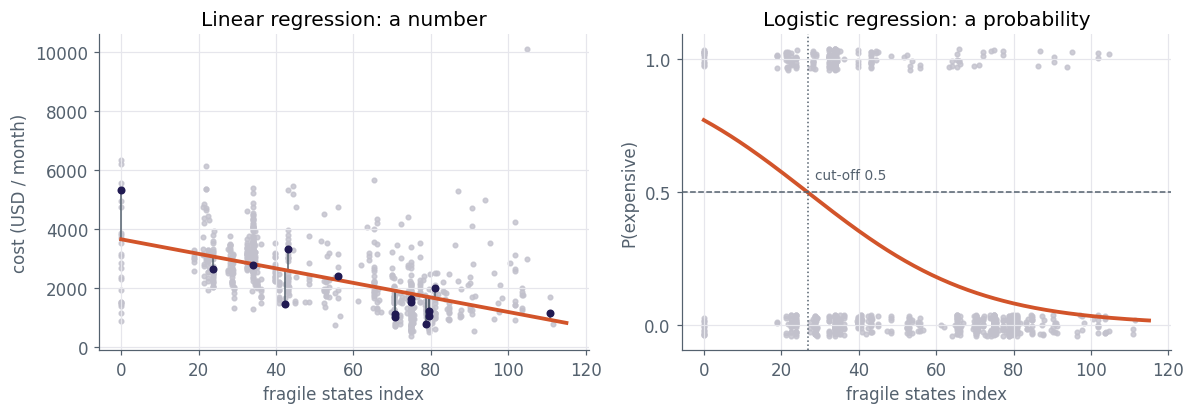

In [12]:
# @title Draw both { display-mode: "form" }
grid = pd.DataFrame({"fragile_states_index": np.linspace(0, 115, 200)})
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.9))
a.scatter(fsi, y, s=9, color=LAV, alpha=.8)
some = cities.sample(15, random_state=3).index
for i in some:
    a.plot([fsi.loc[i, "fragile_states_index"]] * 2, [y[i], line.predict(fsi.loc[[i]])[0]], color=GREY, lw=1)
a.scatter(fsi.loc[some], y[some], s=18, color=NAVY, zorder=3)
a.plot(grid, line.predict(grid), color=ORANGE, lw=2.5)
a.set(title="Linear regression: a number", xlabel="fragile states index", ylabel="cost (USD / month)")
jitter = expensive + np.random.default_rng(0).uniform(-.04, .04, len(expensive))
b.scatter(fsi, jitter, s=9, color=LAV, alpha=.8)
b.plot(grid, logit1.predict_proba(grid)[:, 1], color=ORANGE, lw=2.5)
b.axhline(.5, color=GREY, ls="--", lw=1); b.axvline(cut, color=GREY, ls=":", lw=1)
b.text(cut + 2, .55, "cut-off 0.5", color=GREY, fontsize=9)
b.set(title="Logistic regression: a probability", xlabel="fragile states index", ylabel="P(expensive)",
      yticks=[0, .5, 1])
plt.tight_layout(); plt.show()

One feature already explains a good part of cost, and the S-curve already sorts most cities. The rest of the
notebook adds features and flexibility, and has to show that this helps on cities the model has not seen.

---
# 📏 3 · Honest evaluation

### First, a baseline
Before any model: predict the **average cost** for every city. Every model has to beat that.

In [13]:
baseline = mean_absolute_error(y_test, np.full(len(y_test), y_train.mean()))
print(f"baseline MAE on held-out cities: {baseline:,.0f} USD")

baseline MAE on held-out cities: 903 USD


For Aalborg, the average (about 2,330) is off by almost 1,900; the neighbours were off by about 840.
A model's error only means something next to a baseline.

### Train-test split
The model trains on 80 % of the rows; the other 20 % are held back. The test score estimates performance
on the next city. Five models, each scored on its training rows and on the held-back rows:

In [14]:
# Five models, from very flexible to very rigid. Scaling sits inside a pipeline where distances matter.
models = {"1-nearest neighbour":  make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=1)),
          "tree, no depth limit": DecisionTreeRegressor(random_state=0),
          "linear regression":    make_pipeline(StandardScaler(), LinearRegression()),
          "tree, depth 3":        DecisionTreeRegressor(max_depth=3, random_state=0),
          "random forest":        RandomForestRegressor(n_estimators=300, random_state=0)}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)                                          # learn from the training cities only
    rows.append((name, mean_absolute_error(y_train, model.predict(X_train)),   # error on cities it has seen
                       mean_absolute_error(y_test, model.predict(X_test))))    # error on cities it has not
pd.DataFrame(rows, columns=["model", "train MAE", "test MAE"]).set_index("model").round(0)

,train MAE,test MAE
model,,
1-nearest neighbour,14.0,734.0
"tree, no depth limit",7.0,723.0
linear regression,631.0,697.0
"tree, depth 3",572.0,623.0
random forest,198.0,549.0


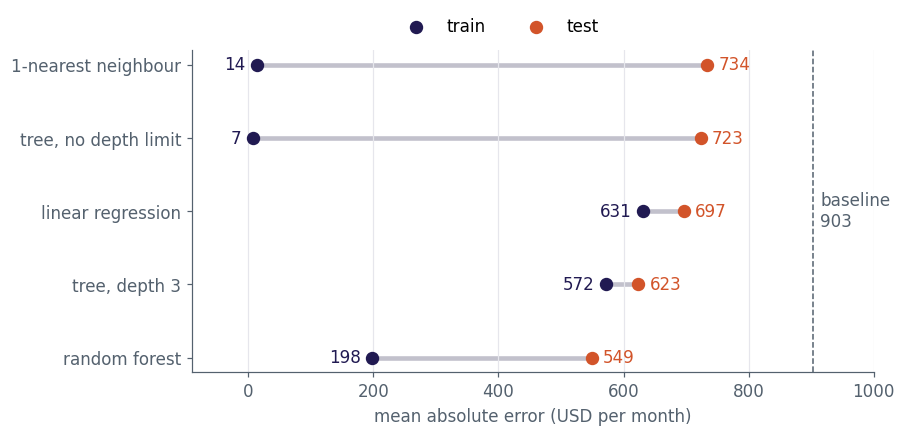

In [15]:
# @title Draw train vs test { display-mode: "form" }
fig, ax = plt.subplots(figsize=(8, 3.8))
for i, (n, tr, te) in enumerate(rows[::-1]):
    ax.plot([tr, te], [i, i], color=LAV, lw=3, zorder=1)
    ax.scatter(tr, i, color=NAVY, s=60, zorder=2, label="train" if i == 0 else None)
    ax.scatter(te, i, color=ORANGE, s=60, zorder=2, label="test" if i == 0 else None)
    ax.text(te + 18, i, f"{te:.0f}", va="center", color=ORANGE); ax.text(tr - 18, i, f"{tr:.0f}", va="center", ha="right", color=NAVY)
ax.axvline(baseline, color=GREY, ls="--", lw=1); ax.text(baseline + 12, 2, f"baseline\n{baseline:.0f}", color=GREY, va="center")
ax.set_yticks(range(len(rows)), [r[0] for r in rows[::-1]]); ax.set(xlabel="mean absolute error (USD per month)", xlim=(-90, 1000))
ax.grid(axis="y", visible=False); ax.legend(loc="lower center", bbox_to_anchor=(0.45, 1.0), ncol=2)
plt.show()

The unlimited tree and 1-NN are near-perfect on training and among the worst on test: they memorised the
training cities. The ranking by training error is almost the reverse of the ranking by test error.

### Cross-validation
One split is one roll of the dice. 5-fold CV trains on four folds, scores the fifth, and rotates: five scores,
an average and a spread. It gives a more stable estimate; it does not reduce overfitting by itself.

In [16]:
for n in ["linear regression", "random forest"]:
    s = -cross_val_score(models[n], X_train, y_train, cv=5, scoring="neg_mean_absolute_error")
    print(f"{n:18s} mean {s.mean():,.0f}   spread {s.std():,.0f}")

linear regression  mean 656   spread 66
random forest      mean 546   spread 51


### ⚖️ Bias and variance

<img src="https://raw.githubusercontent.com/aaubs/ds-master/main/media/M1_2026/sml09/memorising.jpg" width="460">

- **Bias**: too simple to capture the pattern (underfitting). *Depth-3 tree.*
- **Variance**: so flexible it fits the noise (overfitting). *Unlimited tree, 1-NN.*
- **Irreducible error**: noise no model can explain.

The aim is the complexity where test error is lowest. The trade-off measured for kNN, with $k$ as the knob:

In [17]:
# k is the complexity knob of kNN: k=1 copies the nearest city, k=400 averages almost everything
ks = [1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 75, 100, 200, 400]
train_err, test_err = [], []
for k in ks:
    m = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k)).fit(X_train, y_train)
    train_err.append(mean_absolute_error(y_train, m.predict(X_train)))
    test_err.append(mean_absolute_error(y_test, m.predict(X_test)))
print("lowest test error at k =", ks[int(np.argmin(test_err))])

lowest test error at k = 20


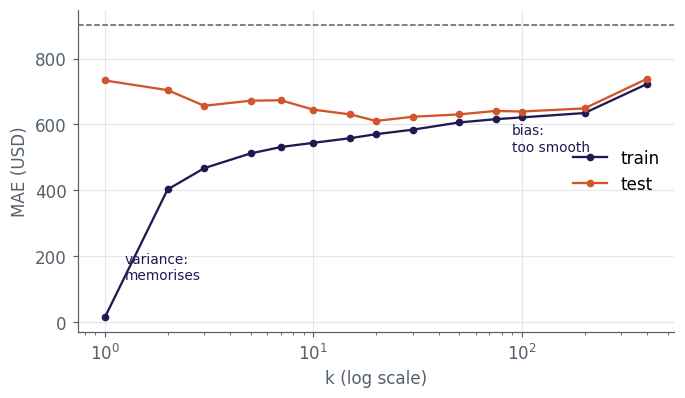

In [18]:
# @title Draw the curve { display-mode: "form" }
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(ks, train_err, marker="o", ms=4, color=NAVY, label="train"); ax.plot(ks, test_err, marker="o", ms=4, color=ORANGE, label="test")
ax.axhline(baseline, color=GREY, ls="--", lw=1)
ax.text(1.25, 130, "variance:\nmemorises", color=NAVY, fontsize=9); ax.text(90, 520, "bias:\ntoo smooth", color=NAVY, fontsize=9)
ax.set(xscale="log", xlabel="k (log scale)", ylabel="MAE (USD)"); ax.legend(loc="center right")
plt.show()

$$E\big[(y - \hat f(x))^2\big] = \text{Var}\big(\hat f(x)\big) + \text{Bias}\big(\hat f(x)\big)^2 + \text{Var}(\epsilon)$$

Draw many training sets, fit the model on each, predict Aalborg: **variance** is how much those predictions
jump around, **bias** is how far their average sits from the truth.

Regularisation trades a little bias for a lot less variance: Lasso (L1) pushes coefficients to zero,
Ridge (L2) shrinks them all, Elastic net mixes both. Note that scikit-learn calls the strength $\lambda$ `alpha`,
and the mix `l1_ratio`.

### 🧭 Side quest: bias and variance, drawn

That definition can be run literally. Draw 20 different training sets of 200 cities, fit the same kind of
model on each, and draw all 20 prediction curves on top of each other. One feature again, so the curves
fit on a page.

In [19]:
grid = pd.DataFrame({"fragile_states_index": np.linspace(5, 112, 200)})
rng = np.random.default_rng(1)
curves = {}
for k in [1, 20, 100]:                                   # very flexible, balanced, very rigid
    curves[k] = []
    for _ in range(20):
        idx = rng.choice(len(cities), 200, replace=False)   # a different training set each time
        m = KNeighborsRegressor(n_neighbors=k).fit(fsi.iloc[idx], y.iloc[idx])
        curves[k].append(m.predict(grid))
    spread = np.std(curves[k], axis=0).mean()
    print(f"k = {k:3d}: average spread between the 20 curves {spread:,.0f} USD")

k =   1: average spread between the 20 curves 849 USD
k =  20: average spread between the 20 curves 197 USD
k = 100: average spread between the 20 curves 90 USD


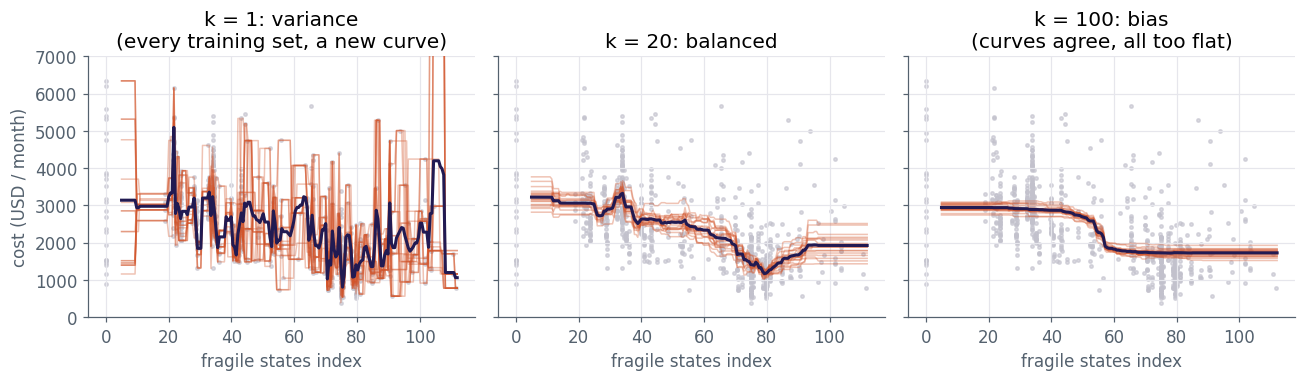

In [20]:
# @title Draw the 20 curves { display-mode: "form" }
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
titles = {1: "k = 1: variance\n(every training set, a new curve)", 20: "k = 20: balanced",
          100: "k = 100: bias\n(curves agree, all too flat)"}
for ax, (k, cs) in zip(axes, curves.items()):
    ax.scatter(fsi, y, s=5, color=LAV, alpha=.6)
    for c in cs:
        ax.plot(grid, c, color=ORANGE, lw=1, alpha=.35)
    ax.plot(grid, np.mean(cs, axis=0), color=NAVY, lw=2)
    ax.set(title=titles[k], xlabel="fragile states index", ylim=(0, 7000))
axes[0].set_ylabel("cost (USD / month)")
plt.tight_layout(); plt.show()

Orange: the 20 fitted curves. Navy: their average. On the left the curves disagree wildly: that spread is
**variance**. On the right they agree, but their average is too flat and misses the drop in cost: that is
**bias**. In the middle, both are small, which is exactly where the test error was lowest.

### 🚰 Leakage: is the feature available at prediction time?

<img src="https://raw.githubusercontent.com/aaubs/ds-master/main/media/M1_2026/sml09/leakage.jpg" width="440">

🤔 *Question: for a city without a cost report, would the price of a coworking desk be known?*

In [21]:
def linear_r2(cols):
    a, b, c, d = train_test_split(cities[cols], y, test_size=0.2, random_state=42)
    return r2_score(d, make_pipeline(StandardScaler(), LinearRegression()).fit(a, c).predict(b))
print(f"with the other price columns:    R² = {linear_r2(FEATURES + OTHER_PRICES):.2f}")
print(f"without the other price columns: R² = {linear_r2(FEATURES):.2f}")
print("coffee equals beer in every row:", (cities.coffee_in_cafe == cities.cost_beer).all())

with the other price columns:    R² = 0.74
without the other price columns: R² = 0.37
coffee equals beer in every row: True


A feature is only legitimate if it exists when the prediction is made. Leakage makes a model look excellent
in the notebook and fail the day it is used. (Also: Samara's `racism` score was 1.8 × 10²⁸ on a 0–1 scale. It
was found because one cross-validation fold blew up. A wildly bad fold is often a data problem.)

---
# 🎯 4 · Classification: is this city expensive?

`y = 1` if `cost_nomad` is above 3,000 USD. 28 % of cities are expensive.

The comparison that matters is a model that always answers "not expensive".

In [22]:
yc = (cities["cost_nomad"] > 3000).astype(int)
Xa, Xb, ya, yb = train_test_split(X, yc, test_size=0.2, random_state=42, stratify=yc)
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xa, ya)
proba = logit.predict_proba(Xb)[:, 1]
print(f"logistic regression accuracy: {accuracy_score(yb, proba >= 0.5):.2f}")
print(f"'never expensive' accuracy:   {1 - yb.mean():.2f}")
print("confusion matrix (rows = actual cheap/expensive):\n", confusion_matrix(yb, proba >= 0.5))
print(f"precision {precision_score(yb, proba >= 0.5):.2f} · recall {recall_score(yb, proba >= 0.5):.2f}")

logistic regression accuracy: 0.76
'never expensive' accuracy:   0.72
confusion matrix (rows = actual cheap/expensive):
 [[103  10]
 [ 28  15]]
precision 0.60 · recall 0.35


With unbalanced classes, accuracy hides most of what matters. Precision: of the cities flagged as expensive,
how many are? Recall: of the expensive cities, how many are flagged? The model outputs a probability, and
the 0.5 cut-off is a choice:

In [23]:
# predict() uses a 0.5 cut-off; with predict_proba the cut-off is ours to choose
thresholds = np.arange(0.1, 0.81, 0.05)
sweep = pd.DataFrame({"threshold": thresholds.round(2),
                      "precision": [precision_score(yb, proba >= t, zero_division=0) for t in thresholds],
                      "recall":    [recall_score(yb, proba >= t) for t in thresholds],
                      "accuracy":  [accuracy_score(yb, proba >= t) for t in thresholds]})
print(f"ROC-AUC {roc_auc_score(yb, proba):.2f}: how well the probabilities rank expensive above cheap")
sweep[sweep.threshold.isin([0.3, 0.5])].round(2)

ROC-AUC 0.83: how well the probabilities rank expensive above cheap


,threshold,precision,recall,accuracy
4,0.3,0.52,0.77,0.74
8,0.5,0.60,0.35,0.76


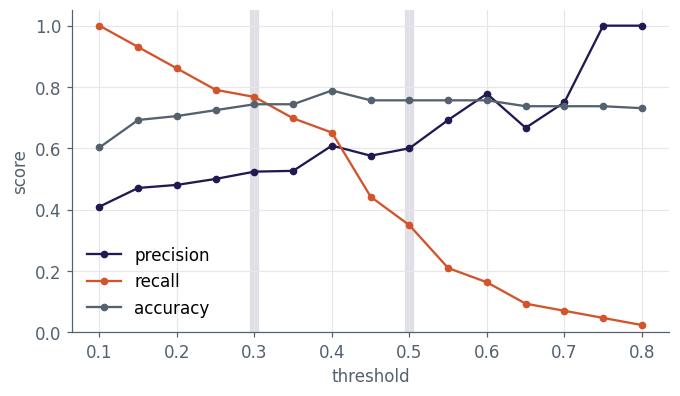

In [24]:
# @title Draw the sweep { display-mode: "form" }
fig, ax = plt.subplots(figsize=(7, 3.8))
for k, c in zip(["precision", "recall", "accuracy"], [NAVY, ORANGE, GREY]):
    ax.plot(sweep.threshold, sweep[k], marker="o", ms=4, color=c, label=k)
for t in (0.3, 0.5):
    ax.axvline(t, color=LAV, lw=6, alpha=0.5, zorder=0)
ax.set(xlabel="threshold", ylabel="score", ylim=(0, 1.05)); ax.legend(loc="lower left")
plt.show()

🤔 *Question: which threshold is right?*

<img src="https://raw.githubusercontent.com/aaubs/ds-master/main/media/M1_2026/sml09/threshold.jpg" width="440">

It depends on what each mistake costs. A **miss**: a client is promised a budget that won't hold. A **false
alarm**: an analyst checks a city that was fine. Different costs, different cut-off. *(Session 10.)*

---
# 🌳 5 · Model families and interpretation

- **Linear models**: linear and logistic regression, plus Ridge, Lasso, Elastic net. Fast, stable, readable;
  they miss curves and interactions unless these are built in as features.
- **Neighbour models**: kNN. Small `k` = high variance, large `k` = high bias; needs scaling.
- **Trees**: recursive splits. **Random forests** average many deep trees; **gradient boosting** (XGBoost) adds
  shallow trees that fix each other's errors *(session 10)*.
- **Neural networks**: MLPs, RNNs, transformers, GNNs *(module 4)*. On tabular business data, a tuned tree
  ensemble is usually the stronger baseline.

A real tree, depth 2, predicting "expensive" for all 780 cities:

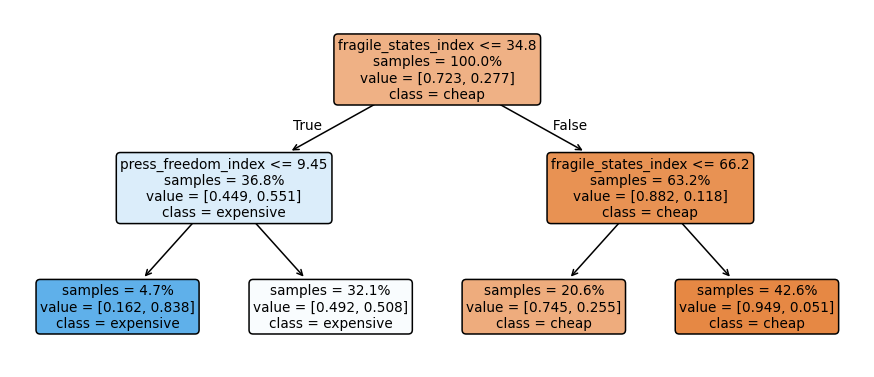

In [25]:
# A tree small enough to read: two questions deep
tree = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X, yc)
fig, ax = plt.subplots(figsize=(10, 4.2))
plot_tree(tree, feature_names=FEATURES, class_names=["cheap", "expensive"], filled=True, rounded=True,
          impurity=False, proportion=True, ax=ax)
plt.show()

A lower press freedom index means a freer press.

### What drives the prediction?
Coefficients (effect of a feature, **others held fixed**), feature importance (trees), and SHAP (one
prediction at a time).

🤔 *Question: `life_score` correlates positively with cost. What sign should its coefficient have?*

In [26]:
# Correlation looks at one feature at a time; a coefficient is the effect with all other features held fixed
lin = models["linear regression"]                        # fitted above; features were standardised
coef = pd.Series(lin[-1].coef_, index=FEATURES)          # USD per one standard deviation of the feature
corr = X_train.corrwith(y_train)
show = ["fragile_states_index", "life_score", "freedom_score", "press_freedom_index", "peace_score", "internet_speed"]
pd.DataFrame({"correlation": corr[show], "coefficient": coef[show]}).round(2)

,correlation,coefficient
fragile_states_index,-0.52,-707.67
life_score,0.34,-676.80
freedom_score,0.45,-187.82
press_freedom_index,-0.46,-148.70
peace_score,0.37,267.88
internet_speed,0.28,147.52


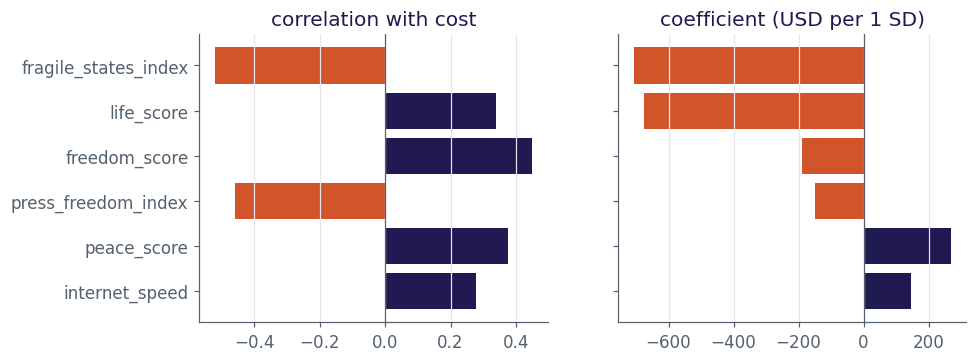

In [27]:
# @title Draw correlation vs coefficient { display-mode: "form" }
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
for ax, s, title in [(axes[0], corr[show], "correlation with cost"), (axes[1], coef[show], "coefficient (USD per 1 SD)")]:
    ax.barh(show[::-1], s[show[::-1]], color=[ORANGE if v < 0 else NAVY for v in s[show[::-1]]])
    ax.axvline(0, color=GREY, lw=0.8); ax.set_title(title, color=NAVY); ax.grid(axis="y", visible=False)
plt.show()

Holding the others fixed, what's left of `life_score` points the other way: it overlaps with freedom, peace and
stability. All of these tools describe **the model, not the world**. The fragile states index predicts cost; it
doesn't cause it. Prediction versus causation is one of the module's learning objectives.

---
# 🧪 6 · Practice: pipelines and tuning

Preprocessing belongs inside a pipeline, so that the scaler learns from the training rows only. Hyperparameters
are chosen with cross-validation on the training set, and the test set is used once, at the end.

In [28]:
search = GridSearchCV(make_pipeline(StandardScaler(), KNeighborsRegressor()),
                      {"kneighborsregressor__n_neighbors": [1, 3, 5, 10, 20]},
                      cv=5, scoring="neg_mean_absolute_error").fit(X_train, y_train)
print("best k:", search.best_params_["kneighborsregressor__n_neighbors"],
      f"| CV MAE {-search.best_score_:,.0f} | test MAE {mean_absolute_error(y_test, search.predict(X_test)):,.0f}")

best k: 10 | CV MAE 608 | test MAE 645


---
# 📋 Wrap-up

- Unsupervised learning asks what structure is in `X`. Supervised learning asks what `y` is, given `X`.
- The difference is the answer key, which makes error measurable.
- Beat a baseline, measure on unseen data, check for leakage.
- Balance bias and variance; regularisation and ensembles help.
- Pick metrics for the decision: accuracy is rarely enough.
- Interpretation describes the model, not causation.

Exercises (save a copy in Drive before starting):
- [Part 1 · Eight questions, eight tools](https://colab.research.google.com/github/aaubs/ds-master/blob/main/notebooks/M1_09_1_from_uml_to_sml.ipynb): optional practice after class. Eight questions a client might ask; for each, pick the tool that answers it
- [Part 2 · Predicting Airbnb prices in Copenhagen](https://colab.research.google.com/github/aaubs/ds-master/blob/main/notebooks/M1_09_2_airbnb_price_prediction.ipynb): the same workflow on messy real data

*Session 10:* gradient boosting, temporal splits, calibration, thresholds from business costs.